11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


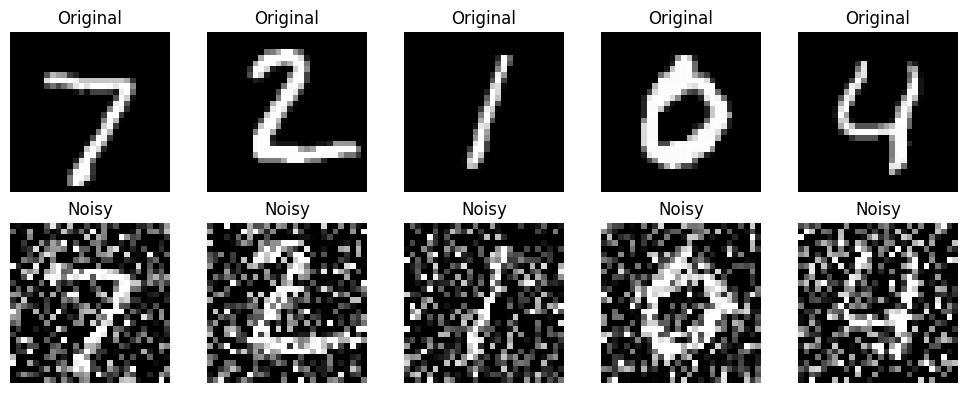

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# 1. Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# 2. Normalize images to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3. Reshape to (28, 28, 1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# 4. Add Gaussian noise (noise factor = 0.5)
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# 5. Clip values to [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# 6. Visualize original and noisy images
n = 5  # number of images to display

plt.figure(figsize=(10, 4))

for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

# Input layer
input_img = Input(shape=(28, 28, 1))

# Encoder

x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# 🔹 Decoder

x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

# Final output layer
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

#  Model

autoencoder = Model(input_img, decoded)

# Compile model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

Training Code

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Optional: save best model
checkpoint = ModelCheckpoint("best_autoencoder.h5",
                             monitor='val_loss',
                             save_best_only=True,
                             verbose=1)

# Train the model
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[checkpoint]
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 0.2956
Epoch 1: val_loss improved from None to 0.12130, saving model to best_autoencoder.h5



Epoch 1: finished saving model to best_autoencoder.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 114s 240ms/step - loss: 0.1895 - val_loss: 0.1213
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - loss: 0.1197
Epoch 2: val_loss improved from 0.12130 to 0.11226, saving model to best_autoencoder.h5



Epoch 2: finished saving model to best_autoencoder.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 231ms/step - loss: 0.1174 - val_loss: 0.1123
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - loss: 0.1124
Epoch 3: val_loss improved from 0.11226 to 0.10846, saving model to best_autoencoder.h5



Epoch 3: finished saving model to best_autoencoder.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 225ms/step - loss: 0.1113 - val_loss: 0.1085
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 0.1088
Epoch 4: val_loss improved from 0.10846 to 0.10577, saving model to best_autoencoder.h5



Epoch 4: finished saving model to best_autoencoder.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 106s 226ms/step - loss: 0.1082 - val_loss: 0.1058
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 0.1064
Epoch 5: val_loss improved from 0.10577 to 0.10466, saving model to best_autoencoder.h5


...


Epoch 6: finished saving model to best_autoencoder.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 106s 225ms/step - loss: 0.1046 - val_loss: 0.1031
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.1039
Epoch 7: val_loss improved from 0.10307 to 0.10244, saving model to best_autoencoder.h5



Epoch 7: finished saving model to best_autoencoder.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 106s 227ms/step - loss: 0.1036 - val_loss: 0.1024
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 0.1029
Epoch 8: val_loss improved from 0.10244 to 0.10143, saving model to best_autoencoder.h5



Epoch 8: finished saving model to best_autoencoder.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 145s 234ms/step - loss: 0.1027 - val_loss: 0.1014
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - loss: 0.1022
Epoch 9: val_loss improved from 0.10143 to 0.10116, saving model to best_autoencoder.h5



Epoch 9: finished saving model to best_autoencoder.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 231ms/step - loss: 0.1020 - val_loss: 0.1012
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - loss: 0.1015
Epoch 10: val_loss improved from 0.10116 to 0.10025, saving model to best_autoencoder.h5



Epoch 10: finished saving model to best_autoencoder.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 230ms/step - loss: 0.1015 - val_loss: 0.1002


Monitor Training & Validation Loss

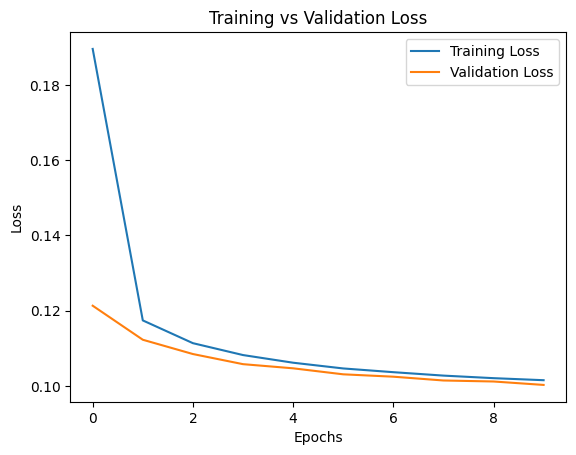

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

1. Predict (Denoise the Images)

In [ ]:
# Generate denoised images
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


2. Visualize Results (Noisy vs Denoised vs Clean)

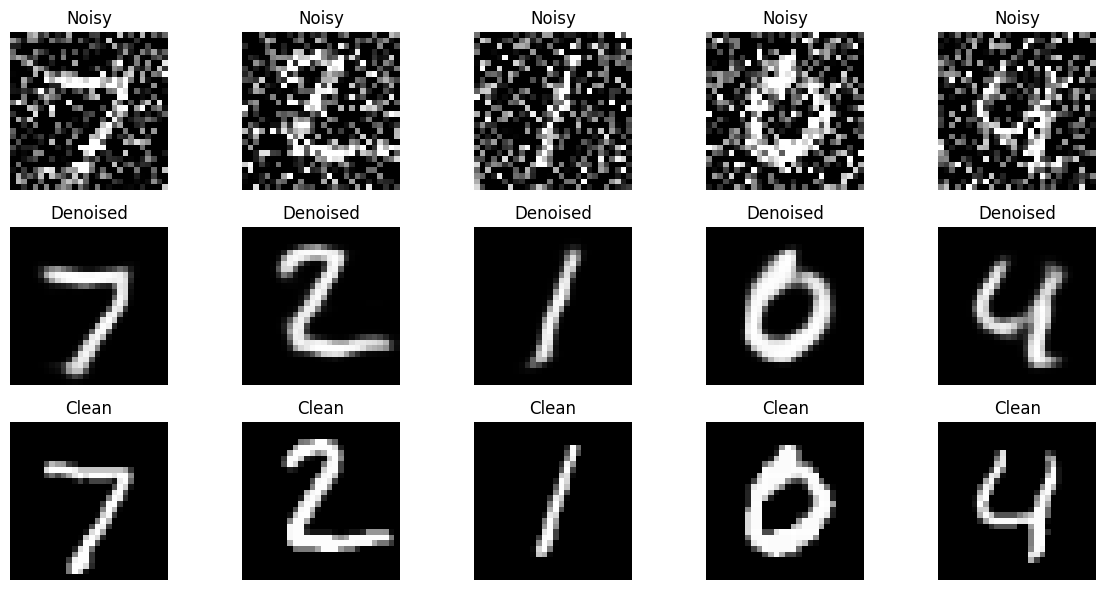

In [ ]:
import matplotlib.pyplot as plt

n = 5  # number of images to display
plt.figure(figsize=(12, 6))

for i in range(n):
    # 🔹 Noisy Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # 🔹 Denoised Image (Output)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # 🔹 Clean Image (Original)
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Clean")
    plt.axis('off')

plt.tight_layout()
plt.show()

1. Dataset Preparation (Devnagari)

In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

# Path to dataset
data_dir = "/content/drive/MyDrive/AI AND ML/Data/DevanagariHandwrittenDigitDataset/Train"

images = []

# Load images using PIL
for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)

        img = Image.open(img_path).convert('L')  # grayscale
        img = img.resize((32, 32))  # resize (important)
        img = np.array(img)

        images.append(img)

# Convert to numpy
images = np.array(images)

# Normalize [0,1]
images = images.astype('float32') / 255.0

# Reshape (add channel)
images = np.reshape(images, (len(images), 32, 32, 1))

# Train-test split
x_train, x_test = train_test_split(images, test_size=0.2, random_state=42)

2. Add Noise (Gaussian)

In [ ]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

3. Build Deep Convolutional Autoencoder (≥ 4 layers)

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(32, 32, 1))

# 🔹 Encoder (Deep)
x = Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# 🔹 Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

# Output layer
decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Model
autoencoder = Model(input_img, decoded)

# Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,761 (194.38 KB)

 Trainable params: 49,761 (194.38 KB)

 Non-trainable params: 0 (0.00 B)

4. Train the Model

In [ ]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 88s 783ms/step - loss: 0.4267 - val_loss: 0.3004
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 78s 730ms/step - loss: 0.2652 - val_loss: 0.2419
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 77s 723ms/step - loss: 0.2305 - val_loss: 0.2206
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 87s 772ms/step - loss: 0.2153 - val_loss: 0.2129
Epoch 5/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 78s 726ms/step - loss: 0.2054 - val_loss: 0.2014
Epoch 6/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 77s 725ms/step - loss: 0.1992 - val_loss: 0.1967
Epoch 7/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 77s 719ms/step - loss: 0.1949 - val_loss: 0.1941
Epoch 8/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 81s 711ms/step - loss: 0.1909 - val_loss: 0.1916
Epoch 9/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 82s 714ms/step - loss: 0.1877 - val_loss: 0.1887
Epoch 10/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 77s 720ms/step - loss: 0.1855 - val_loss: 0.1852
Epoch 11/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 81s 713ms/step - loss: 0.1831 - val_loss: 0.1817
Epoch 12/15
107/107

5. Plot Loss Curve

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

6. Evaluate & Visualize

In [ ]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 5
plt.figure(figsize=(12,6))

for i in range(n):
    # Noisy
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(32,32), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(32,32), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # Original
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(x_test[i].reshape(32,32), cmap='gray')
    plt.title("Clean")
    plt.axis('off')

plt.show()

7. Experiment & Fine-Tuning

In [ ]:
noise_factor = 0.2  # less noise
noise_factor = 0.7  # more noise